In [ ]:
#THESIS CODE: LOTKA-VOLTERRA SIMULATIONS 

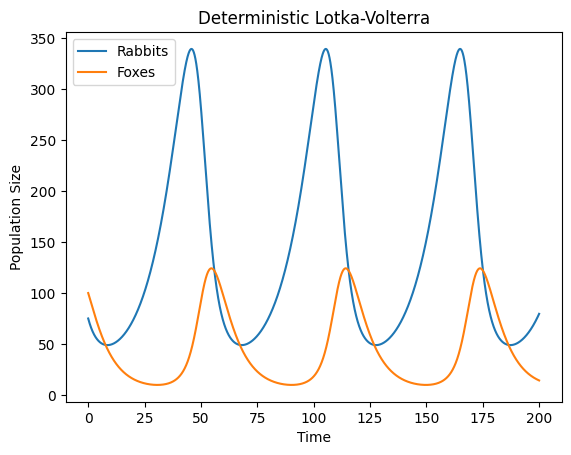

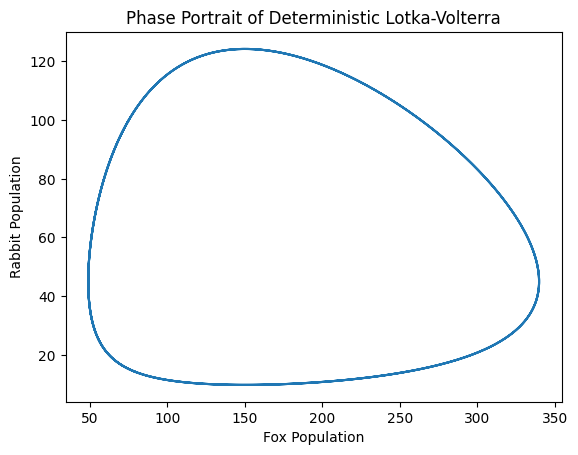

In [40]:
# LOTKA VOLTERRA MODEL BASIC SIMULATION 
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import numpy as npy
import random

# timestep determines the accuracy of the euler method of integration
timestep = 0.0001
# amplitude of noise term
amp = 0.00
# the time at which the simulation ends
end_time = 200

# creates a time vector from 0 to end_time, seperated by a timestep
t = npy.arange(0,end_time,timestep)

# intialize rabbits (x) and foxes (y) vectors
x = []
y = []

# noise term to perturb differential equations
def StochasticTerm(amp):
    return (amp * random.uniform(-1,1))

"""" definition of lotka-volterra parameters"""
# birth rate of rabbits (alpha)
a = 0.09
# death rate of rabbits due to predation (beta)
b = 0.002
# natural death rate of foxes (gamma)
c = 0.15
# factor that describes how many eaten rabbits give birth to a new fox (delta)
d = 0.001

""" euler integration """

# initial conditions for the rabbit (x) and fox (y) populations at time=0
x.append(75)
y.append(100)

# forward euler method of integration
# a perturbbation term is added to the differentials to make the simulation stochastic
for index in range(1,len(t)):
    
    # make parameters stochastic
#     a = a + StochasticTerm(amp)
#     b = b + StochasticTerm(amp)
#     c = c + StochasticTerm(amp)
#     d = d + StochasticTerm(amp)
    
    # evaluate the current differentials
    xd = x[index-1] * (a - b*y[index-1])
    yd = -y[index-1]*(c - d*x[index-1])
    
    # evaluate the next value of x and y using differentials
    next_x = x[index-1] + xd * timestep
    next_y = y[index-1] + yd * timestep

    # add the next value of x and y 
    x.append(next_x)
    y.append(next_y)

""" visualization """

if amp == 0:    
    # visualization of deterministic populations against time
    plt.plot(t, x)
    plt.plot(t, y)
    plt.xlabel('Time')
    plt.ylabel('Population Size')
    plt.legend(('Rabbits', 'Foxes'))
    plt.title('Deterministic Lotka-Volterra')
    plt.show()

    # deterministic phase portrait
    plt.plot(x,y)
    plt.xlabel('Fox Population')
    plt.ylabel('Rabbit Population')
    plt.title('Phase Portrait of Deterministic Lotka-Volterra')
    plt.show()
    
else:
    # visualization of stochastic populations against time
    plt.plot(t, x)
    plt.plot(t, y)
    plt.xlabel('Time')
    plt.ylabel('Population Size')
    plt.legend(('Rabbits', 'Foxes'))
    plt.title('Stochastic Lotka-Volterra')
    plt.show()

    # stochastic phase portrait
    plt.plot(x,y)
    plt.xlabel('Fox Population')
    plt.ylabel('Rabbit Population')
    plt.title('Phase Portrait of Stochastic Lotka-Volterra')
    plt.show()
    
    # noise term visualization
    noise = []
    n =[]
    for sample in range(100):
        noise.append(StochasticTerm(amp))
        n.append(sample)

    plt.plot(n, noise)
    plt.xlabel('Arbitrary Noise Samples')
    plt.ylabel('Noise')
    plt.title('Perturbation to Birth Rate')
    plt.show()

In [1]:
# JACOBIAN MATRICES AND EIGENVALUES
import numpy as np 
import scipy.integrate as intgr
import matplotlib.pyplot as plt

r = f = g = d = 1.    # simple values just for illustration

def jac(X, Y):    # calculate Jacobian matrix
    J = np.array([[r-f*Y, -f*X],
                  [g*Y, g*X-d]])
    return J

X0, Y0 = 0, 0    # steady state at (0, 0)
X1, Y1 = d/g, r/f    # the other steady state

for (X,Y) in [(X0,Y0), (X1,Y1)]:
    w, v = np.linalg.eig(jac(X,Y))    # this function calculates all eigenvalues and eigenvectors
    print(f'steady state at {(X, Y)}: eigenvalues = {w}')

steady state at (0, 0): eigenvalues = [ 1. -1.]
steady state at (1.0, 1.0): eigenvalues = [0.+1.j 0.-1.j]


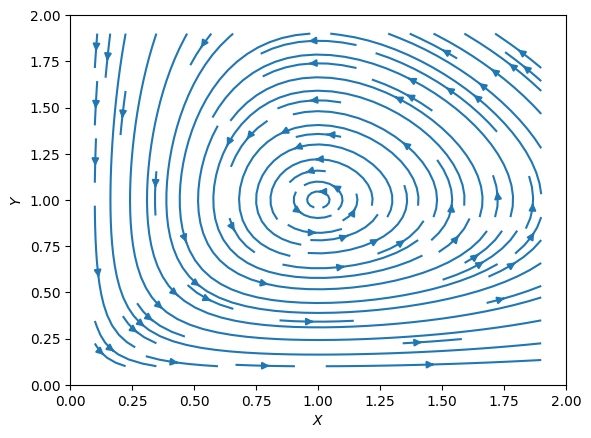

In [2]:
# VISUALIZATION 
x_points = np.arange(0.1, 2., 0.2)    # grid lines for x-axis
y_points = np.arange(0.1, 2., 0.2)    # grid lines for y-axis
x_grid, y_grid = np.meshgrid(x_points, y_points)    # generate a grid of x, y values

x_flow = x_grid * (r - f * y_grid)
y_flow = y_grid * (g * x_grid - d)

plt.figure()
plt.streamplot(x_grid, y_grid, x_flow, y_flow)
plt.xlim(0, 2)
plt.ylim(0, 2)
plt.xlabel(r'$X$')
plt.ylabel(r'$Y$')
plt.show()
